In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import re
from scipy.stats import binomtest
from matplotlib_venn import venn2
import scipy.stats as stats
import math
from gprofiler import GProfiler
from matplotlib_venn import venn2

### Venn Functions

In [128]:
def venn_diagram(l1, l2, g1='g1', g2='g2',t=''):
    venn2([set(l1), set(l2)], set_labels=(f'{g1}', f'{g2}'))
    plt.title(t)
    plt.show()

def save_venn_diagram(l1, l2, g1='g1', g2='g2',t=''):
    venn2([set(l1), set(l2)], set_labels=(f'{g1}', f'{g2}'))
    plt.title(t)
    plt.savefig(f"{t}_{g1}vs{g2}.png")

def intersection(l1,l2):
    return list(set(l1) & set(l2))

In [129]:
def clean_input_list(input_data):
    """
    Helper function to flatten lists of lists and ensure data are strings.
    Example: [['GeneA'], ['GeneB']] -> {'GeneA', 'GeneB'}
    """
    clean_set = set()
    for item in input_data:
        if isinstance(item, (list, tuple, pd.Series)):
            if len(item) > 0:
                clean_set.add(str(item[0]))
        else:
            clean_set.add(str(item))
    return clean_set

def compare_species_lists(mlist, hlist, mslist, hslist):
    """
    Generates 3 Venn diagrams and a detailed report for 6 specific gene categories.
    """
    # --- 1. DATA PREPARATION ---
    M_all = set(mlist)
    H_all = set(hlist)
    M_sig = set(mslist)
    H_sig = set(hslist)

    # Define the "Universe" of Homologs (Genes present in both)
    common_genes = M_all.intersection(H_all)
    
    # Define Non-Significant sets (All - Sig)
    M_nonsig = M_all - M_sig
    H_nonsig = H_all - H_sig

    # --- 2. CALCULATE THE 6 CATEGORIES ---
    
    # (1) Human present sig, Mouse present sig
    # (Intersection of Sig sets within Common genes)
    cat1 = (H_sig & M_sig) & common_genes
    
    # (2) Human present sig, Mouse present nonsig
    # (H is Sig, M is Nonsig, within Common)
    cat2 = (H_sig & M_nonsig) & common_genes
    
    # (3) Human present nonsig, Mouse present sig
    # (H is Nonsig, M is Sig, within Common)
    cat3 = (H_nonsig & M_sig) & common_genes
    
    # (4) Human present nonsig, Mouse present nonsig
    # (Both are Nonsig, within Common)
    cat4 = (H_nonsig & M_nonsig) & common_genes
    
    # (5) Human absent, Mouse present
    # (Strictly unique to Mouse list)
    cat5 = M_all - H_all
    
    # (6) Human present, Mouse absent
    # (Strictly unique to Human list)
    cat6 = H_all - M_all

    # --- 3. PLOTTING THE 3 VENN DIAGRAMS ---
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # DIAGRAM 1: GLOBAL OVERLAP (All Genes)
    # Visualizes Categories 5 and 6 (Species Unique) vs Homologs
    venn2([H_all, M_all], set_labels=('All Human', 'All Mouse'), ax=axes[0])
    axes[0].set_title("1. All Genes (Global Homology)")
    
    # DIAGRAM 2: SIGNIFICANT HOMOLOGS
    # Visualizes Categories 1, 2, and 3
    # We restrict this Venn to ONLY common genes to make the numbers match your logic
    h_sig_common = H_sig & common_genes
    m_sig_common = M_sig & common_genes
    
    #v2 = venn2([h_sig_common, m_sig_common], set_labels=('Human Sig', 'Mouse Sig'), ax=axes[1])
    v2 = venn2([H_sig, M_sig], set_labels=('Human Sig', 'Mouse Sig'), ax=axes[1])
    axes[1].set_title("2. Significant Homologs")
    # Color customization for clarity
    if v2.get_patch_by_id('11'): v2.get_patch_by_id('11').set_color('purple')
    
    # DIAGRAM 3: NON-SIGNIFICANT HOMOLOGS
    # Visualizes Category 4 (and complements)
    h_nonsig_common = H_nonsig & common_genes
    m_nonsig_common = M_nonsig & common_genes
    
    #v3 = venn2([h_nonsig_common, m_nonsig_common], set_labels=('Human Nonsig', 'Mouse Nonsig'), ax=axes[2])
    v3 = venn2([H_nonsig, M_nonsig], set_labels=('Human Nonsig', 'Mouse Nonsig'), ax=axes[2])
    axes[2].set_title("3. Non-Significant Homologs")
    if v3.get_patch_by_id('11'): v3.get_patch_by_id('11').set_color('gray')

    # --- 4. PRINTING THE REPORT ---
    
    print("="*60)
    print("GENE LIST COMPARISON REPORT")
    print("="*60)
    print(f"(1) Human present sig, Mouse present sig:       {len(cat1)}")
    print(f"(2) Human present sig, Mouse present nonsig:    {len(cat2)}")
    print(f"(3) Human present nonsig, Mouse present sig:    {len(cat3)}")
    print(f"(4) Human present nonsig, Mouse present nonsig: {len(cat4)}")
    print("-" * 60)
    print(f"(5) Human absent, Mouse present:                {len(cat5)}")
    print(f"(6) Human present, Mouse absent:                {len(cat6)}")
    print("="*60)
    
    # Add text box to the plot image as well
    stats_text = (
        f"COUNTS:\n"
        f"(1) Both Sig: {len(cat1)}\n"
        f"(2) H Sig / M Nonsig: {len(cat2)}\n"
        f"(3) H Nonsig / M Sig: {len(cat3)}\n"
        f"(4) Both Nonsig: {len(cat4)}\n"
        f"(5) Mouse Unique: {len(cat5)}\n"
        f"(6) Human Unique: {len(cat6)}"
    )
    plt.figtext(0.5, -0.1, stats_text, ha="center", fontsize=12, 
                bbox={"facecolor":"white", "alpha":0.8, "pad":5})
    
    plt.tight_layout(rect=[0, 0.15, 1, 1]) # Make room for text at bottom
    plt.savefig('venn_diagram_all.png')
    plt.show()

### Load Data

In [ ]:
#load data
df1 = pd.read_excel('data/wong_data/many_mouse.xlsx')
df2 = pd.read_csv('data/gers_data/human_downstream.csv')

df1_organism = 'mmusculus'
df2_organism = 'hsapiens'

df1_upstream_col = 'test_gRNAtarget'
df2_upstream_col = 'upstream_gene'

df1_downstream_name_col = 'testgene'
df2_downstream_name_col = 'gene_names'

df1_expression_col = 'glm_coef'
df2_expression_col = 'log2fc'

df1_significance_col = 'fdr'
df2_significance_col = 'pvals_sig_adj'

output_dir = 'sample_results'

In [161]:
def get_parent_gene(name):
    return re.sub(r'-\d+$', '', str(name))

In [101]:
#keep only the common upstream targets
df1_up_gene = set(df1[df1_upstream_col].to_list())
df2_up_gene = set(df2[df2_upstream_col].to_list())

clean = ''
common_up_genes = df1_up_gene.intersection(df2_up_gene)

if len(common_up_genes) == 0:
    clean = 'clean_'
    df1[clean+df1_upstream_col] = df1[df1_upstream_col].apply(get_parent_gene).str.upper()
    df2[clean+df2_upstream_col] = df2[df2_upstream_col].apply(get_parent_gene).str.upper()
    set1 = set(df1[clean+df1_upstream_col].to_list())
    set2 = set(df2[clean+df2_upstream_col].to_list())
    common_up_genes = set1.intersection(set2)

In [116]:
df1 = df1[df1[clean+df1_upstream_col].isin(common_up_genes)].copy()
df2 = df2[df2[clean+df2_upstream_col].isin(common_up_genes)].copy()

In [117]:
#get gene lists
df1_down_genes = list(set(df1[df1_downstream_name_col].to_list()))  
df2_down_genes = list(set(df2[df2_downstream_name_col].to_list()))
df1_sig_down_genes = list(set(df1[df1[df1_significance_col] < 0.05][df1_downstream_name_col]))
df2_sig_down_genes = list(set(df2[df2[df2_significance_col] < 0.05][df2_downstream_name_col]))

### Matching

In [118]:
df2_upper_map = {gene: gene.upper() for gene in df2_down_genes}
df1_upper_map = {gene: gene.upper() for gene in df1_down_genes}

In [119]:
upper_df2_genes = [word.upper() for word in df2_down_genes]
upper_df1_genes = [word.upper() for word in df1_down_genes]
upper_sig_df2_genes = [word.upper() for word in df2_sig_down_genes]
upper_sig_df1_genes = [word.upper() for word in df1_sig_down_genes]

df2_only_genes = list(set(df2_upper_map) - set(upper_df1_genes))
df1_only_genes = list(set(upper_df1_genes) - set(df2_upper_map))

In [120]:
def gp_convert_ENSG(gp, genes, organism = 'hsapiens'):
    if organism == 'hsapiens':  
        results = gp.convert(
            query=genes,
            organism=organism,
            target_namespace='ENSG'
        )
        final = results.drop_duplicates(subset=['incoming'], keep='first')
        final = final.drop_duplicates(subset=['converted'], keep='first')
        only_ensg = final[final['converted'] != 'None']
        only_ensg_map = dict(zip(only_ensg['incoming'],only_ensg['converted']))
        
    else:
        results = gp.orth(
            query=genes,
            organism=organism,  
            target='hsapiens',
        )
        final = results.drop_duplicates(subset=['incoming'], keep='first')
        final = final.drop_duplicates(subset=['ortholog_ensg'], keep='first')
        only_ensg = final[final['ortholog_ensg'] != 'None']
        only_ensg_map = dict(zip(only_ensg['incoming'],only_ensg['ortholog_ensg']))



    return final, only_ensg, only_ensg_map

In [121]:
gp = GProfiler(return_dataframe=True)

df2_converted, only_df2_ensg, only_df2_ensg_map = gp_convert_ENSG(gp, df2_only_genes, df2_organism)
df1_converted, only_df1_ensg, only_df1_ensg_map = gp_convert_ENSG(gp, df1_only_genes, df1_organism)

In [123]:
df2['UP_NAME'] = df2[df2_downstream_name_col].map(df2_upper_map)
df1['UP_NAME'] = df1[df1_downstream_name_col].map(df1_upper_map)

In [124]:
df2['GP_NAME'] = df2[df2_downstream_name_col].map(only_df2_ensg_map)
df1['GP_NAME'] = df1[df1_downstream_name_col].map(only_df1_ensg_map)

df2['DOWNSTREAM_GENE'] = df2['GP_NAME'].fillna(df2['UP_NAME'])
df1['DOWNSTREAM_GENE'] = df1['GP_NAME'].fillna(df1['UP_NAME'])

GENE LIST COMPARISON REPORT
(1) Human present sig, Mouse present sig:       664
(2) Human present sig, Mouse present nonsig:    2970
(3) Human present nonsig, Mouse present sig:    1551
(4) Human present nonsig, Mouse present nonsig: 9213
------------------------------------------------------------
(5) Human absent, Mouse present:                9027
(6) Human present, Mouse absent:                17002


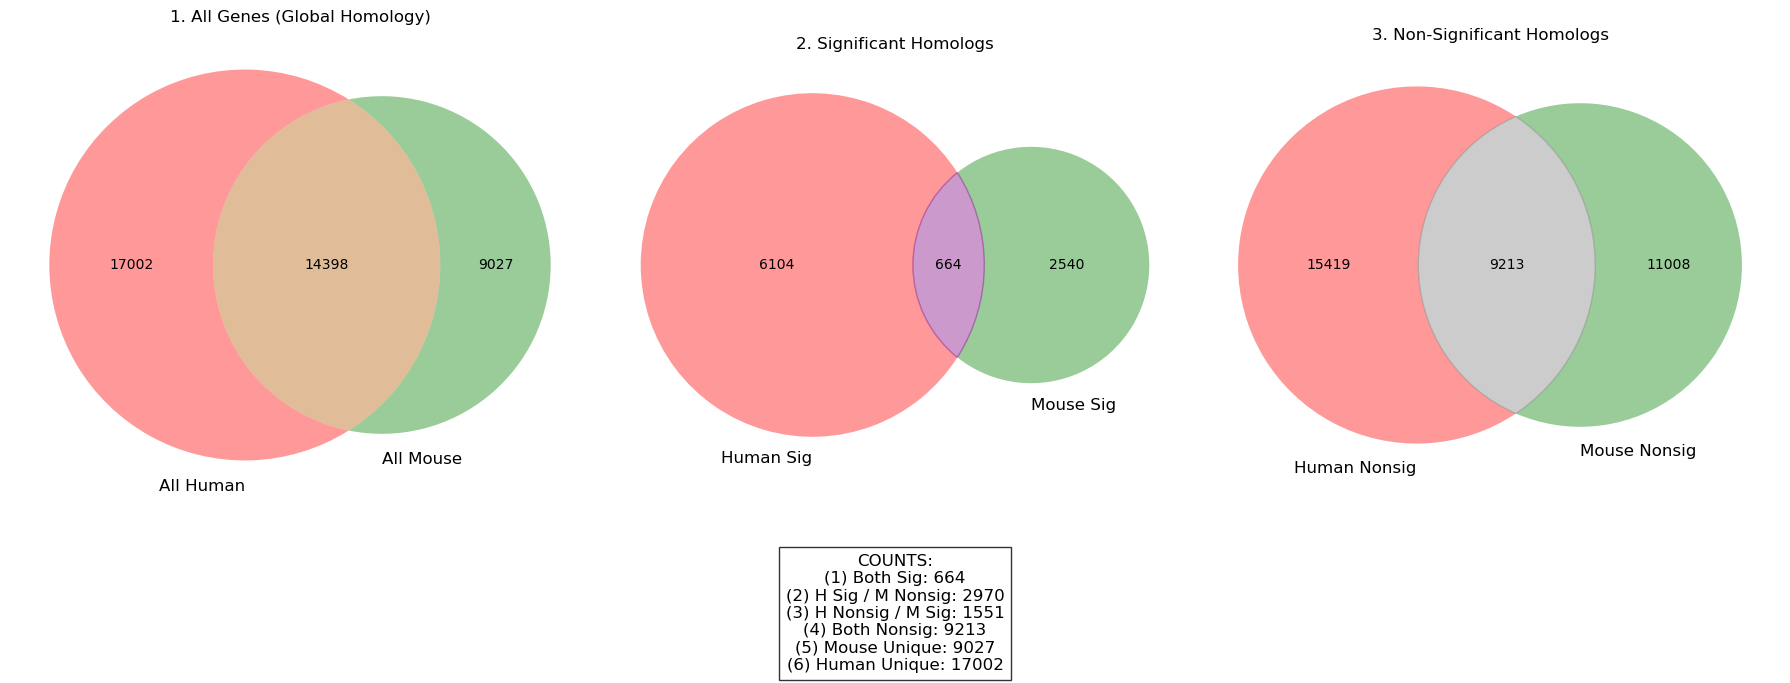

In [130]:
df1list = df1['DOWNSTREAM_GENE'].to_list()
df2list = df2['DOWNSTREAM_GENE'].to_list()
df1_sig_list = df1[df1[df1_significance_col]<0.05]['DOWNSTREAM_GENE'].to_list()
df2_sig_list = df2[df2[df2_significance_col]<0.05]['DOWNSTREAM_GENE'].to_list()
compare_species_lists(df1list, df2list, df1_sig_list, df2_sig_list)

### Tests

In [163]:
def run_rrho(df1, df2, transcript, step_size=200, n_permutations=100):
    parent_gene = transcript.split('-')[0] 
    
    df1_sub = df1[df1[clean+df1_upstream_col] == parent_gene].copy()
    df2_sub = df2[df2[clean+df2_upstream_col] == parent_gene].copy()
    df1_len = len(df1_sub)
    df2_len = len(df2_sub)
    
    # 1. STRICT INTERSECTION
    df1_genes = set(df1_sub['DOWNSTREAM_GENE'])
    df2_genes = set(df2_sub['DOWNSTREAM_GENE'])
    common_genes = df1_genes.intersection(df2_genes)
    
    df1_sub = df1_sub[df1_sub['DOWNSTREAM_GENE'].isin(common_genes)].copy()
    df2_sub = df2_sub[df2_sub['DOWNSTREAM_GENE'].isin(common_genes)].copy()
    
    universe_size = len(common_genes)
    print(f"Subsets length: df1={len(df1_sub)}, df2={len(df2_sub)}")
    print(f"Intersected Universe Size: {universe_size}")
    
    # 2. METRIC CALCULATION
    df1_sub['metric'] = -np.log10(df1_sub[df1_significance_col] + 1e-300) * np.sign(df1_sub[df1_expression_col])
    df2_sub['metric'] = -np.log10(df2_sub[df2_significance_col] + 1e-300) * np.sign(df2_sub[df2_expression_col])
    
    df1_ranked = df1_sub.sort_values('metric', ascending=False)['DOWNSTREAM_GENE'].tolist()
    df2_ranked = df2_sub.sort_values('metric', ascending=False)['DOWNSTREAM_GENE'].tolist()
    
    max_rank = min(len(df1_ranked), len(df2_ranked))
    steps = list(range(10, max_rank, step_size))
    
    # 3. CALCULATE REAL PEAK
    log_pvals_real, real_pval, best_overlap, best_df1_cut, best_df2_cut = _calc_rrho_grid_fast(df1_ranked, df2_ranked, steps, universe_size)
    real_max_log_p = np.max(log_pvals_real)

    # 4. RUN PERMUTATION TEST (Build the Null Distribution)
    print(f"Running {n_permutations} permutations...")
    better_or_equal_count = 0
    df2_ranked_arr = np.array(df2_ranked) # Convert for fast shuffling
    
    for _ in range(n_permutations):
        # Shuffle the mouse list to break the biological relationship
        np.random.shuffle(df2_ranked_arr)
        
        # Calculate peak of the shuffled data
        log_pvals_fake, _, _, _, _ = _calc_rrho_grid_fast(
            df1_ranked, df2_ranked_arr, steps, universe_size
        )
        fake_max_log_p = np.max(log_pvals_fake)
        
        # Tally if the fake peak is stronger than our real biological peak
        if fake_max_log_p >= real_max_log_p:
            better_or_equal_count += 1
            
    # 5. CALCULATE EMPIRICAL P-VALUE
    empirical_pval = (better_or_equal_count + 1) / (n_permutations + 1)
    
    # Flip the heatmap vertically to match your original plotting coordinate logic (0,0 at bottom-left)
    heatmap = log_pvals_real
    
    print(f"Real Peak P-val: {real_pval:.2e} | Empirical P-val: {empirical_pval:.4f}")

    return df1_len, df2_len, best_overlap, empirical_pval, heatmap, best_df1_cut, best_df2_cut,max_rank

def _calc_rrho_grid_fast(df1_ranked, df2_ranked, steps, universe_size):
    """
    Highly optimized helper function to calculate the RRHO matrix.
    Eliminates nested loops by using searchsorted and vectorized hypergeom.
    """
    n_steps = len(steps)
    k_grid = np.zeros((n_steps, n_steps), dtype=int)
    
    # 1. Map human genes to their rank index in the mouse list
    df2_rank_dict = {gene: rank for rank, gene in enumerate(df2_ranked)}
    df1_ranks_in_2 = np.array([df2_rank_dict[g] for g in df1_ranked])
    
    # 2. Fast Overlap Counting
    for i, df1_cut in enumerate(steps):
        # Ranks of the top 'h_cut' human genes in the mouse list
        ranks_in_2 = df1_ranks_in_2[:df1_cut]
        sorted_ranks = np.sort(ranks_in_2)
        
        # Count how many ranks are strictly less than each m_cut step
        k_grid[i, :] = np.searchsorted(sorted_ranks, steps, side='left')
        
    # 3. Vectorized Hypergeometric calculation
    X_size, Y_size = np.meshgrid(steps, steps, indexing='ij')
    
    # sf(k-1, M, n, N) -> M: population, n: human draws, N: mouse draws, k-1: overlaps
    p_vals = stats.hypergeom.sf(k_grid - 1, universe_size, X_size, Y_size)
    
    # Prevent log(0)
    p_vals = np.clip(p_vals, 1e-300, 1.0)
    log_pvals = -np.log10(p_vals)
    
    # 4. Find the Peak
    best_idx = np.unravel_index(np.argmax(log_pvals), log_pvals.shape)
    
    return log_pvals, p_vals[best_idx], k_grid[best_idx], steps[best_idx[0]], steps[best_idx[1]]

def plot(heatmap, t, max_rank): # Added max_rank to the arguments

    plt.figure(figsize=(10, 8))
    
    # 2. Plot with origin='lower' to fix the axes, and extent to show true ranks
    plt.imshow(heatmap, cmap='jet', aspect='auto', interpolation='nearest', 
               origin='lower', extent=[0, max_rank, 0, max_rank])
    
    cbar = plt.colorbar()
    cbar.set_label(r'$-\log_{10}(\text{P-value})$', rotation=270, labelpad=20)
    
    # 4. Update the Labels to reflect standard Cartesian plotting
    plt.xlabel('df2 Rank Position\n(0 = Most Upregulated, Max = Most Downregulated)')
    plt.ylabel('df1 Rank Position\n(0 = Most Upregulated, Max = Most Downregulated)')
    plt.title('RRHO Heatmap')
    
    # Text placement remains the same, as the coordinate space is now correctly aligned
    plt.text(0.05, 0.05, 'Both Up', transform=plt.gca().transAxes, color='white', weight='bold')
    plt.text(0.95, 0.95, 'Both Down', transform=plt.gca().transAxes, color='white', weight='bold', ha='right')
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/{t}.png')

start BANF1-201
12153
sig_h: 13
sig_m: 280
sig_overlap_count: 0
total_overlap_count: 12153
geo_p_value: 1.0
Subsets length: df1=12153, df2=12153
Intersected Universe Size: 12153
Running 100 permutations...
Real Peak P-val: 5.09e-02 | Empirical P-val: 0.9802
df1 cut 6010
df2 cut 10
done BANF1-201
start DPF2-205
12682
sig_h: 219
sig_m: 508
sig_overlap_count: 16
total_overlap_count: 12682
geo_p_value: 0.015070934801886345
Subsets length: df1=12682, df2=24602
Intersected Universe Size: 12682
Running 100 permutations...
Real Peak P-val: 9.99e-01 | Empirical P-val: 0.8218
df1 cut 410
df2 cut 210
done DPF2-205
start DPF2-208
12682
sig_h: 219
sig_m: 508
sig_overlap_count: 16
total_overlap_count: 12682
geo_p_value: 0.015070934801886345
Subsets length: df1=12682, df2=24602
Intersected Universe Size: 12682
Running 100 permutations...
Real Peak P-val: 9.99e-01 | Empirical P-val: 0.7723
df1 cut 410
df2 cut 210
done DPF2-208
start EIF1AD-205
12558
sig_h: 18
sig_m: 200
sig_overlap_count: 0
total_over

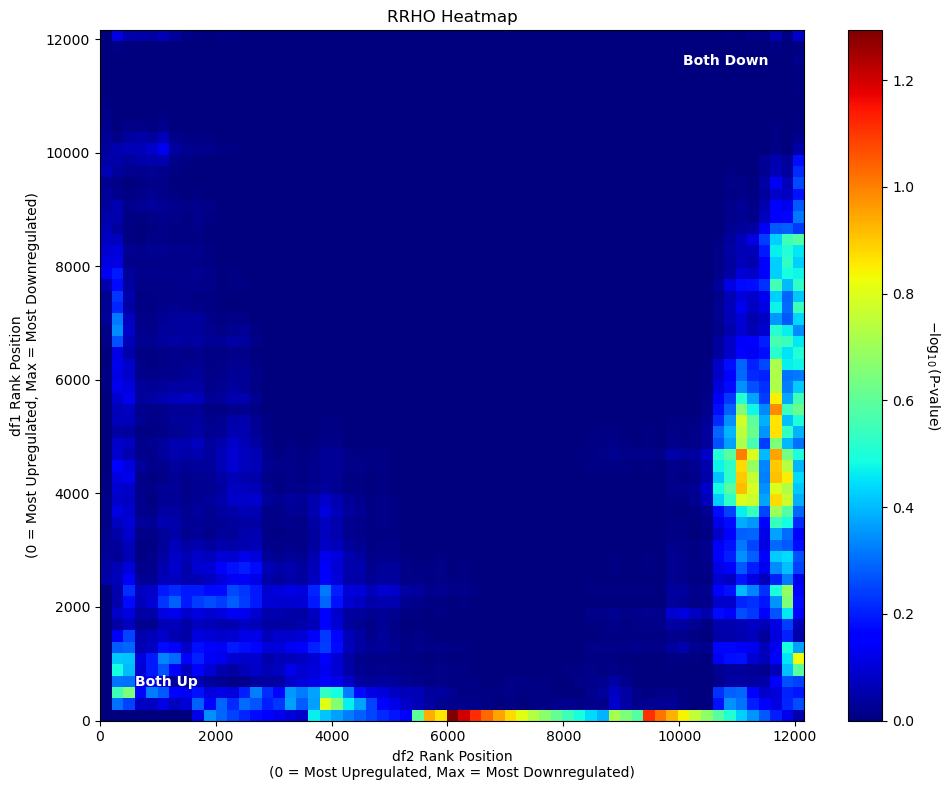

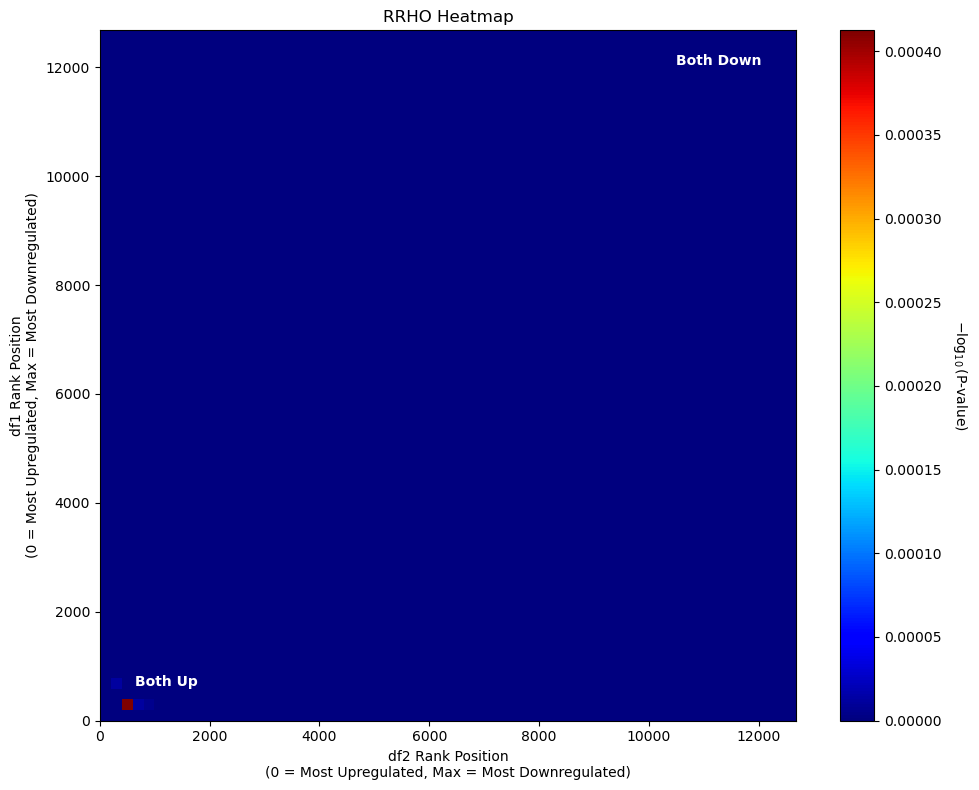

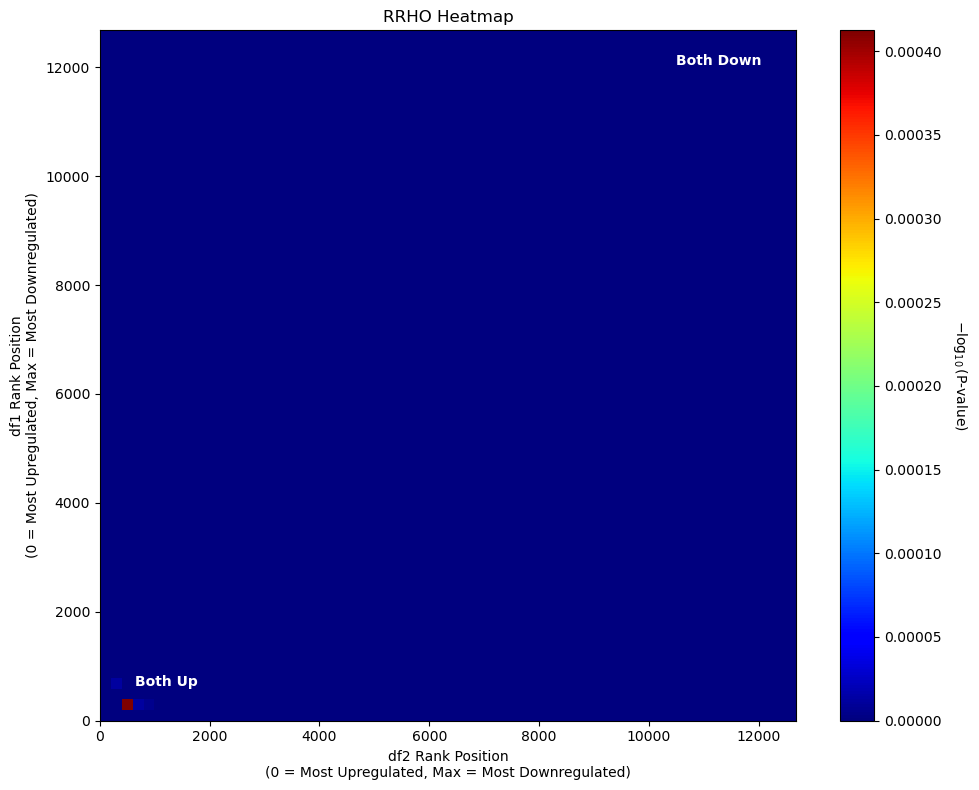

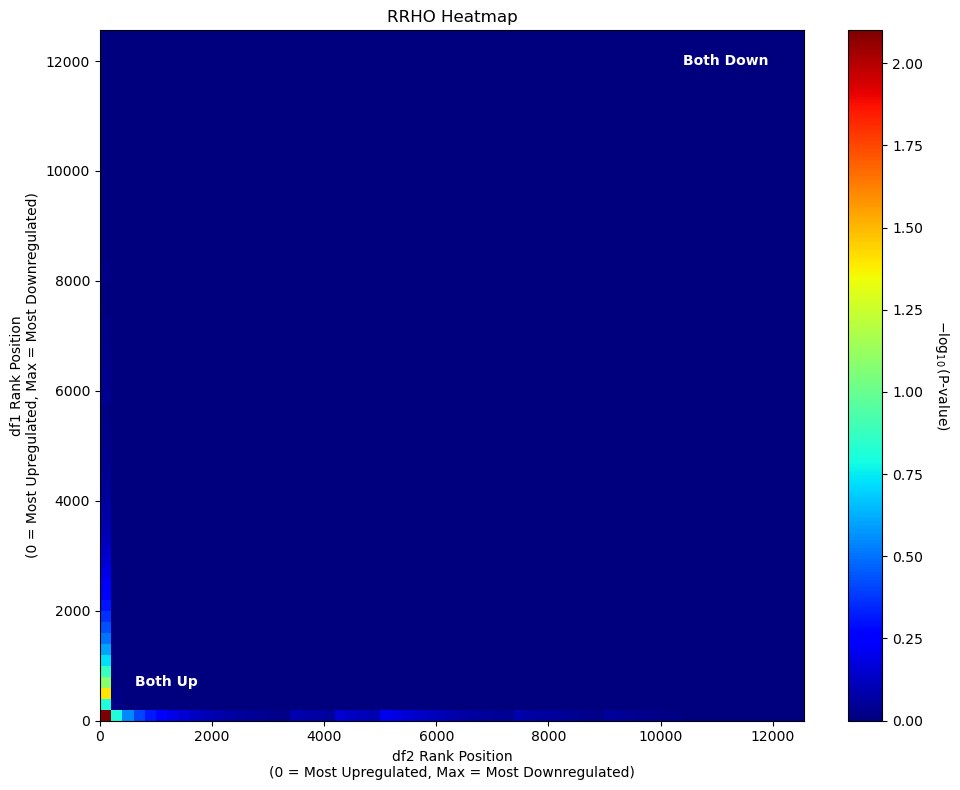

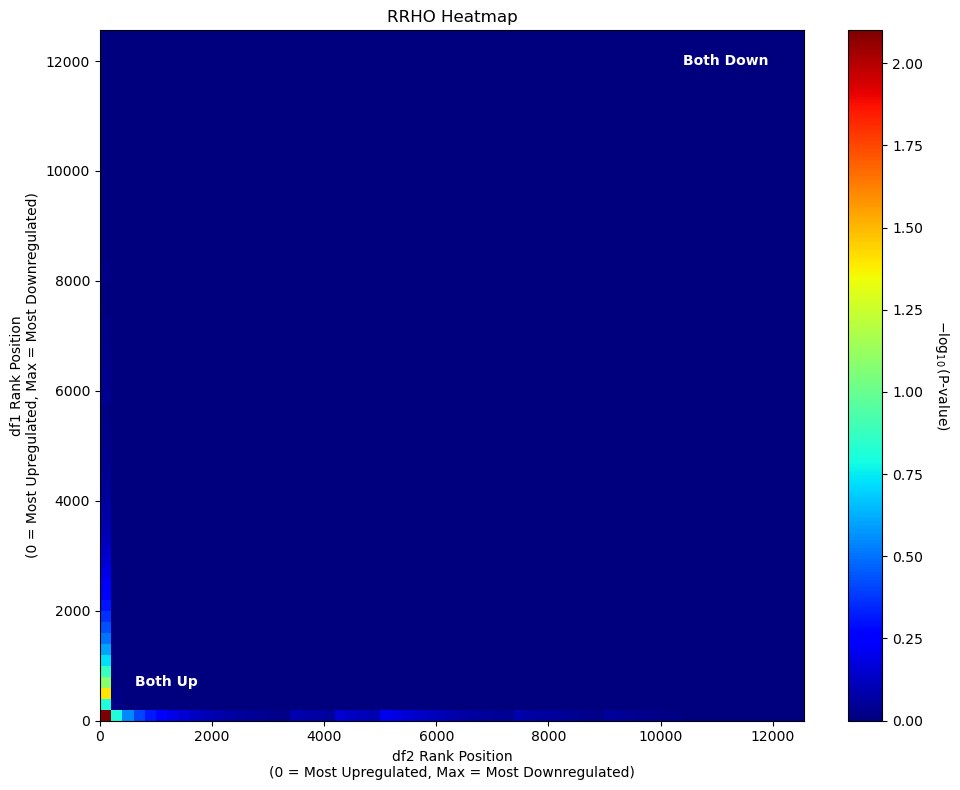

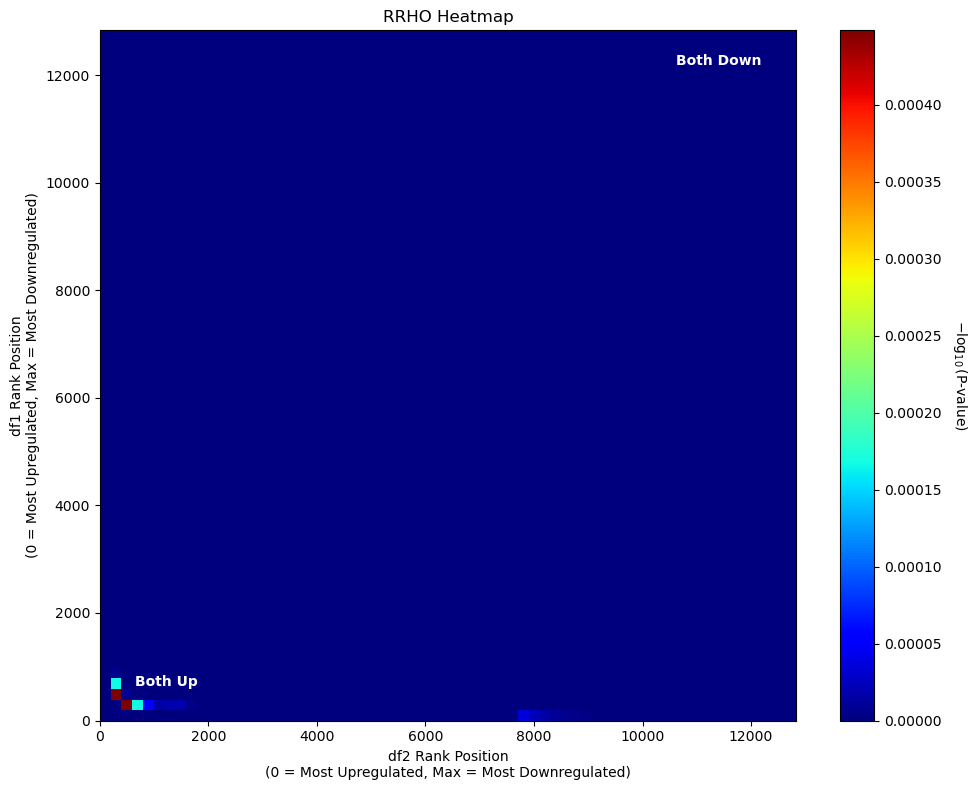

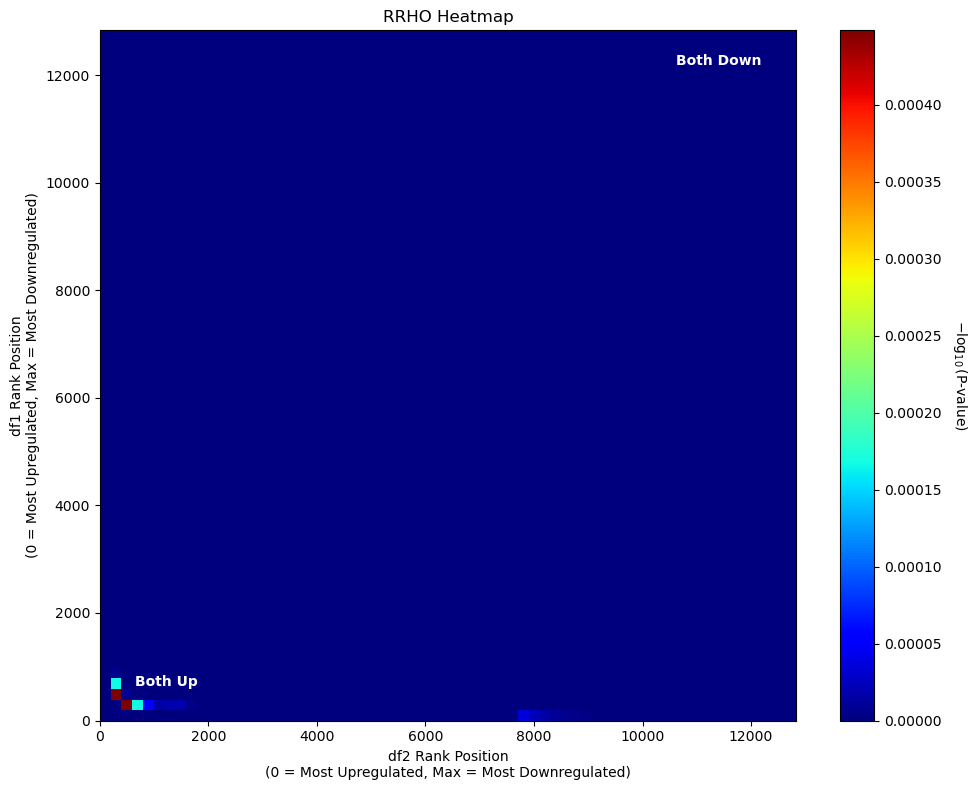

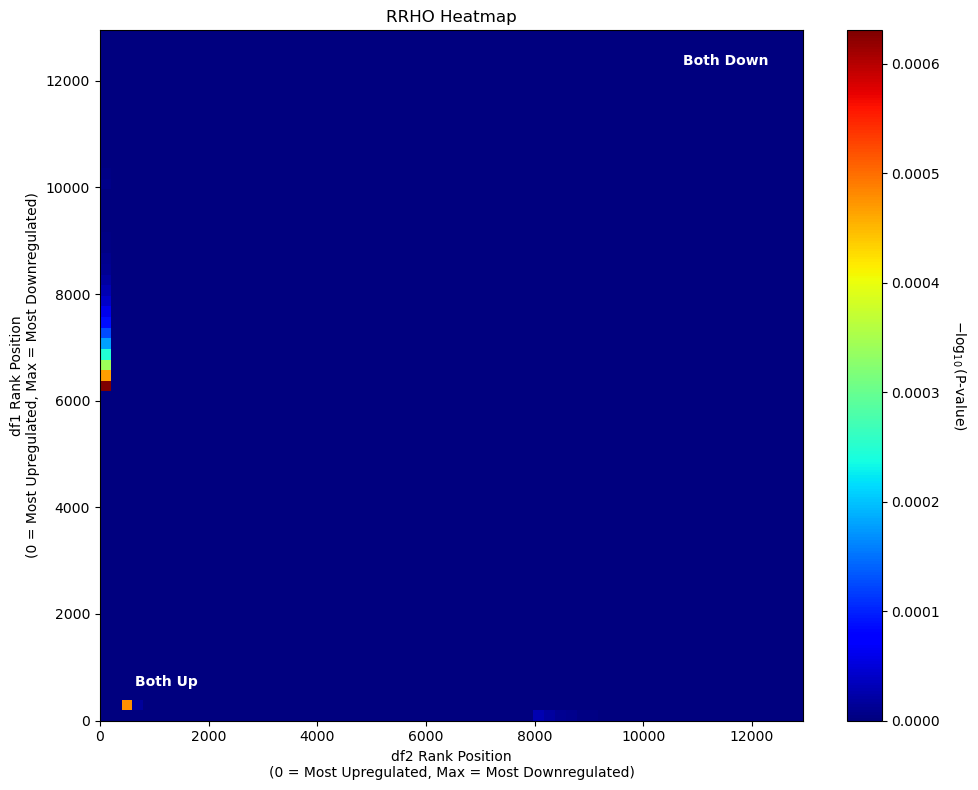

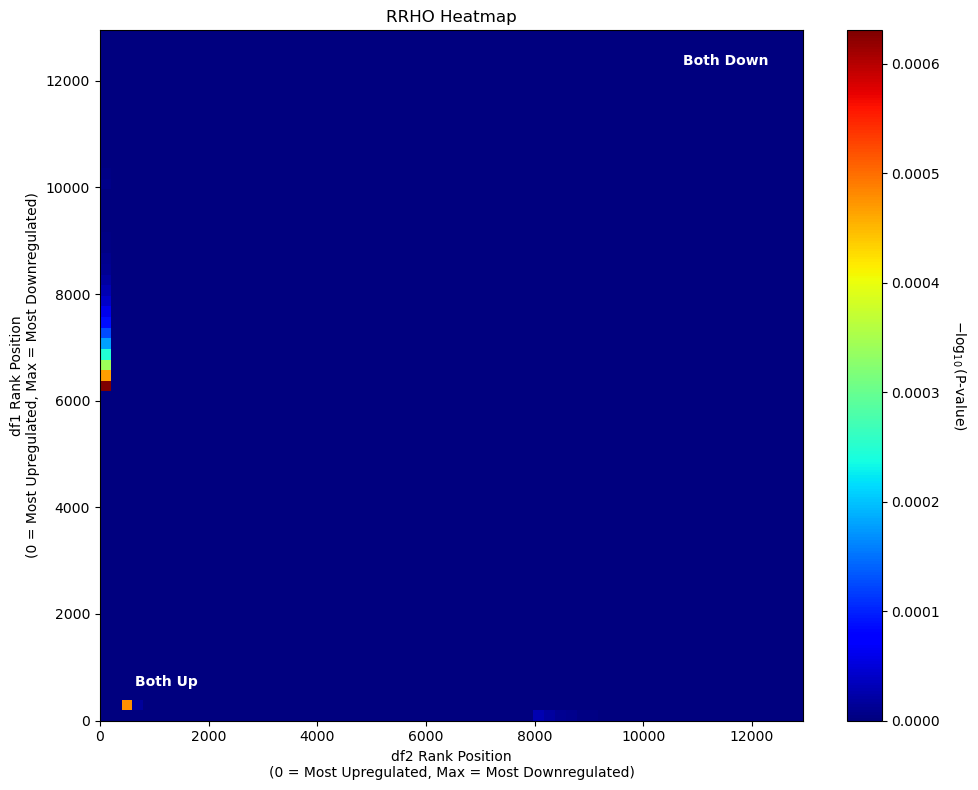

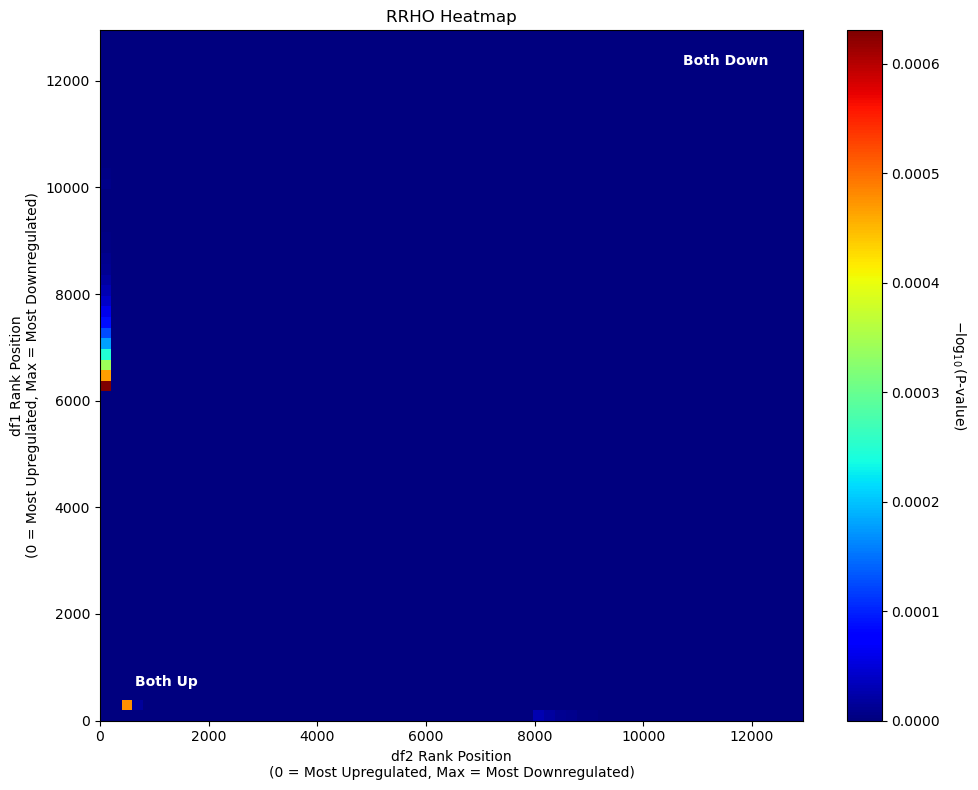

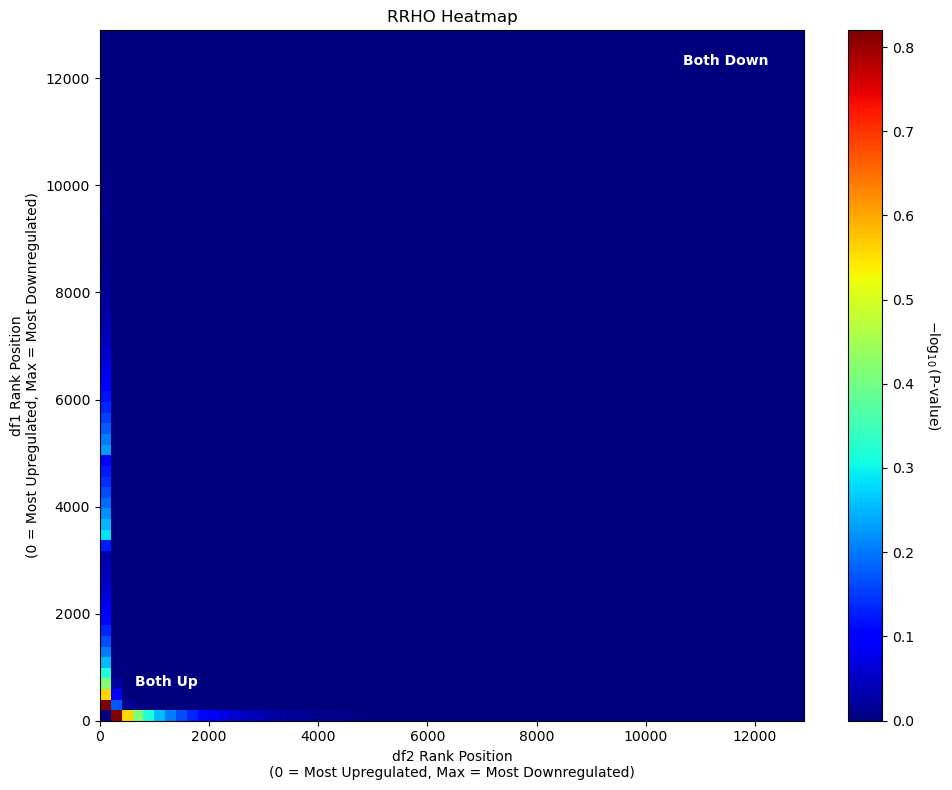

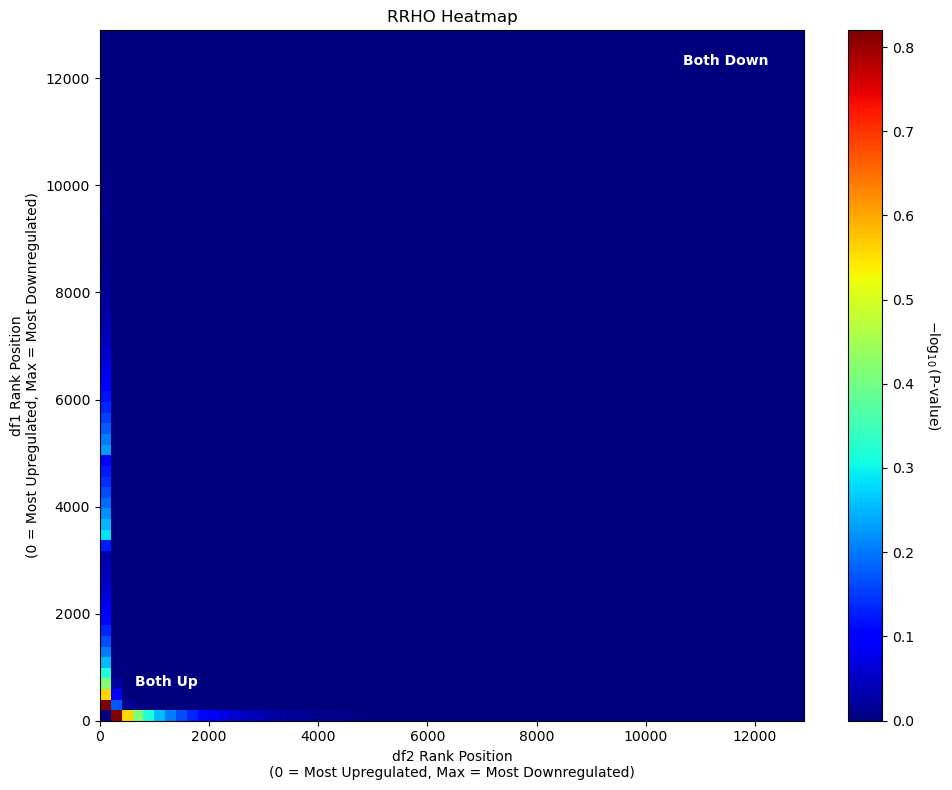

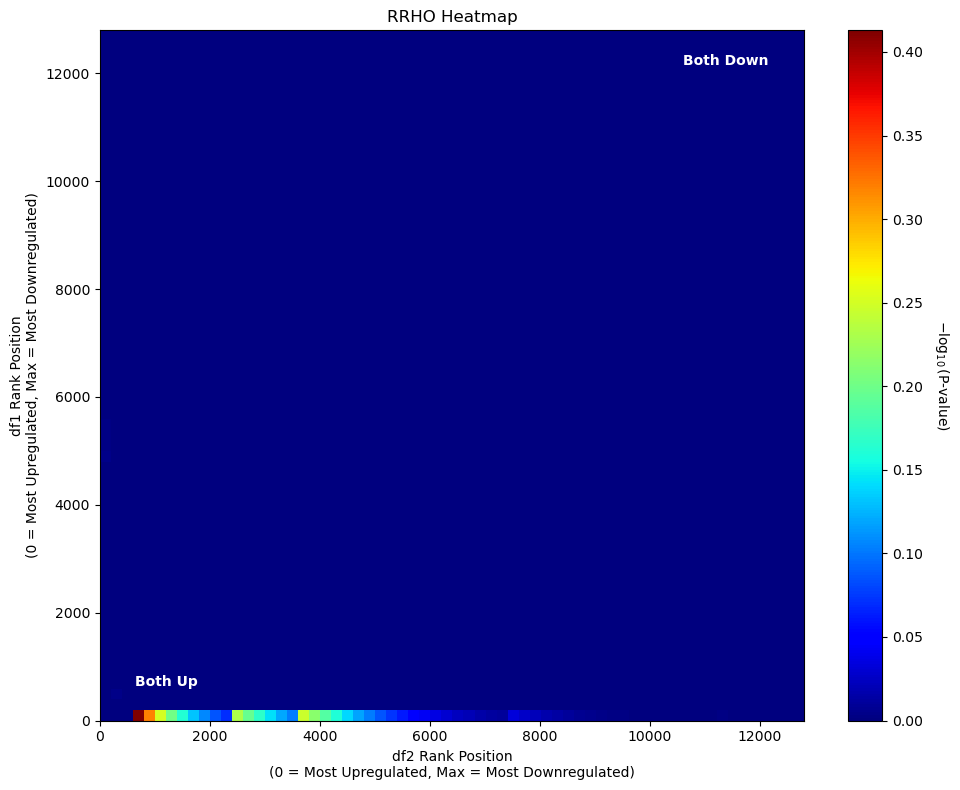

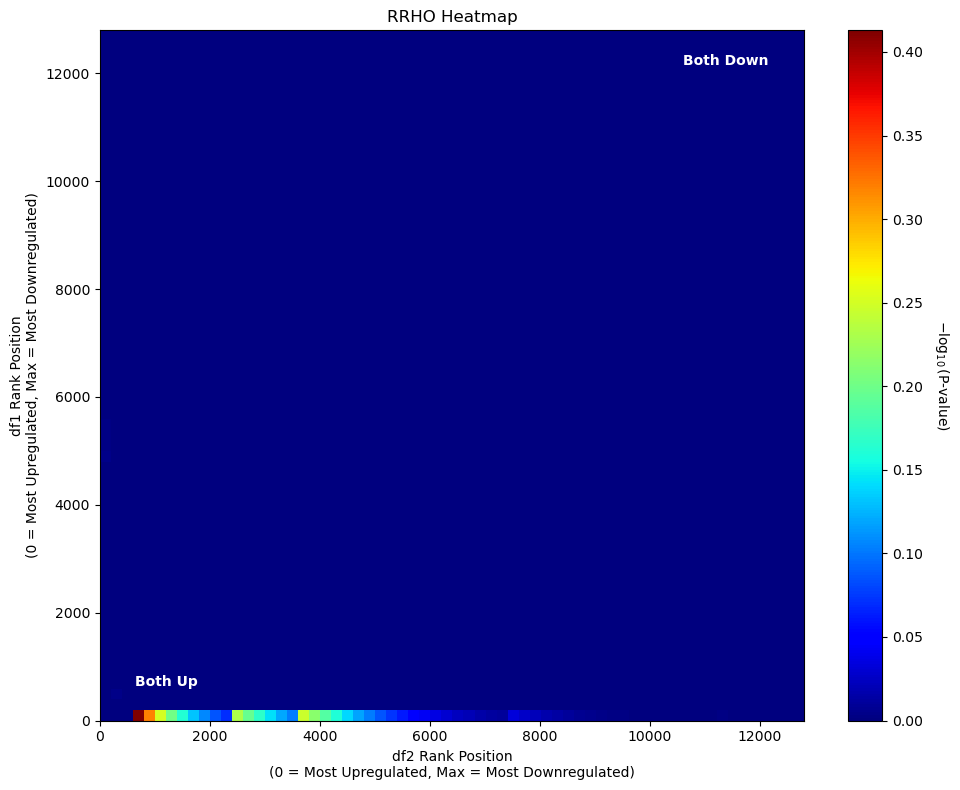

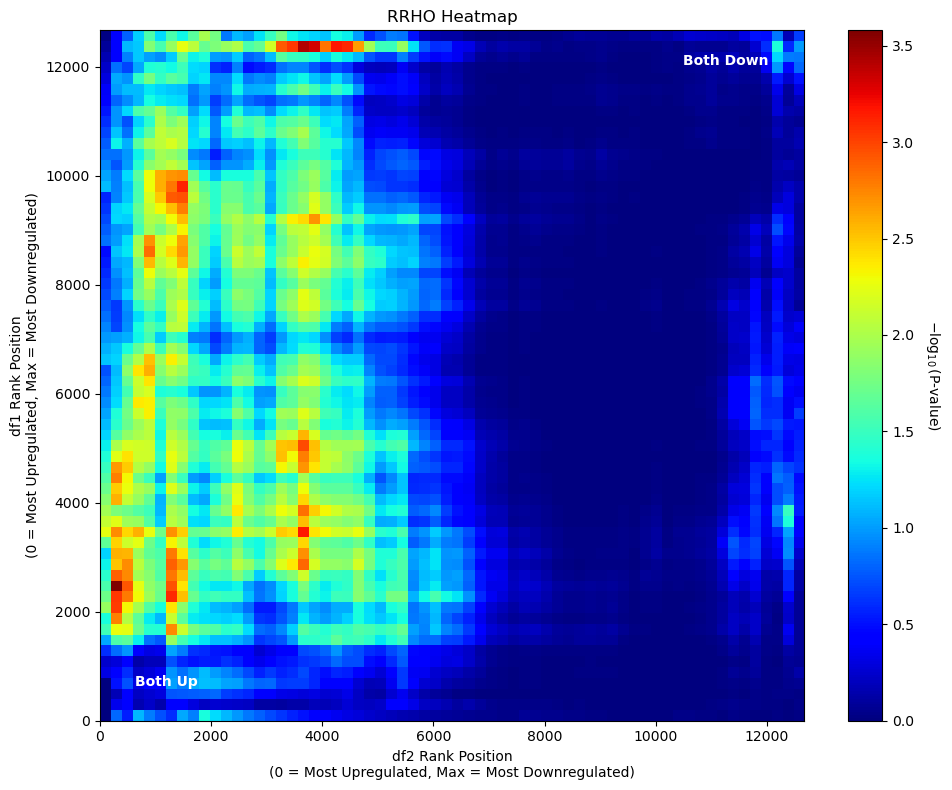

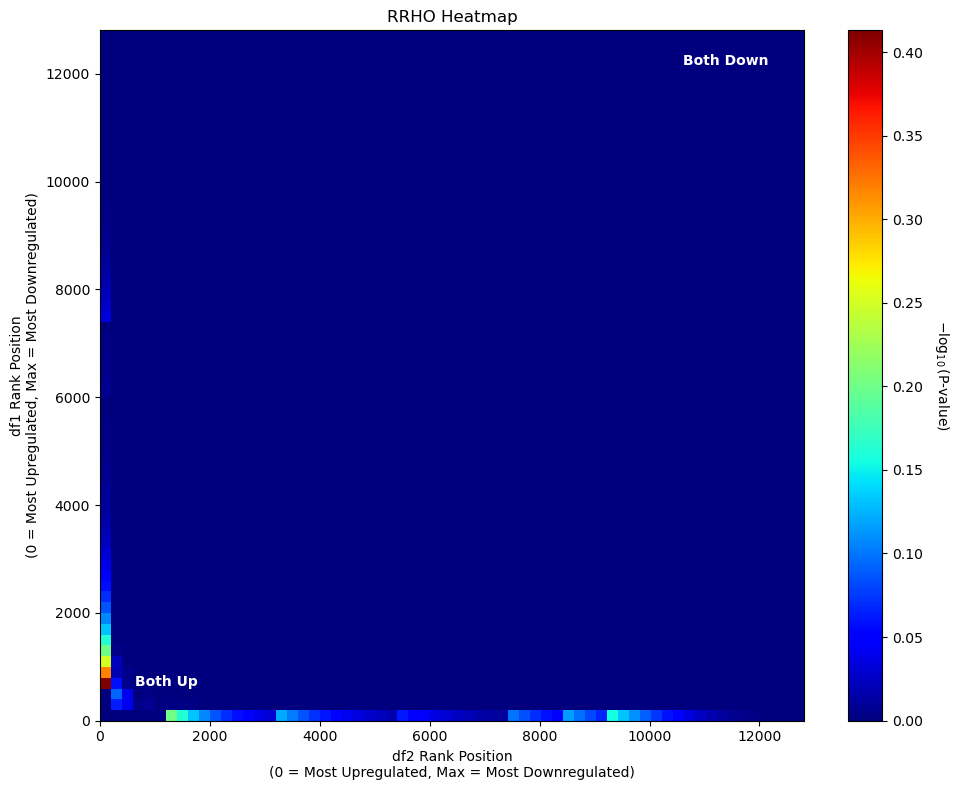

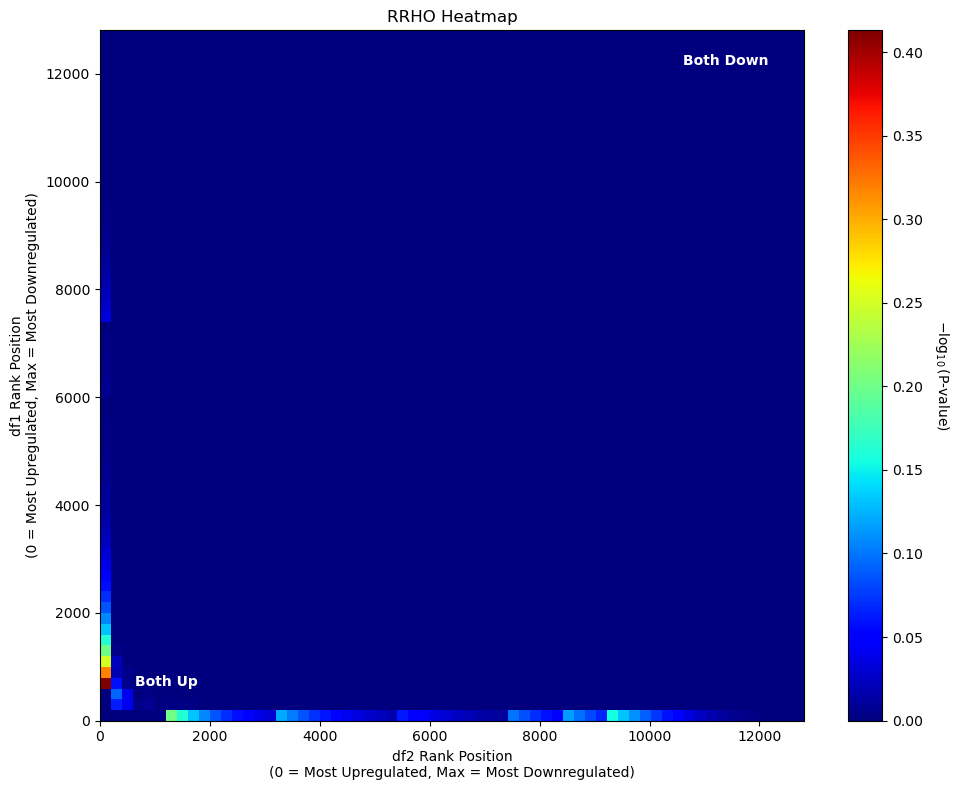

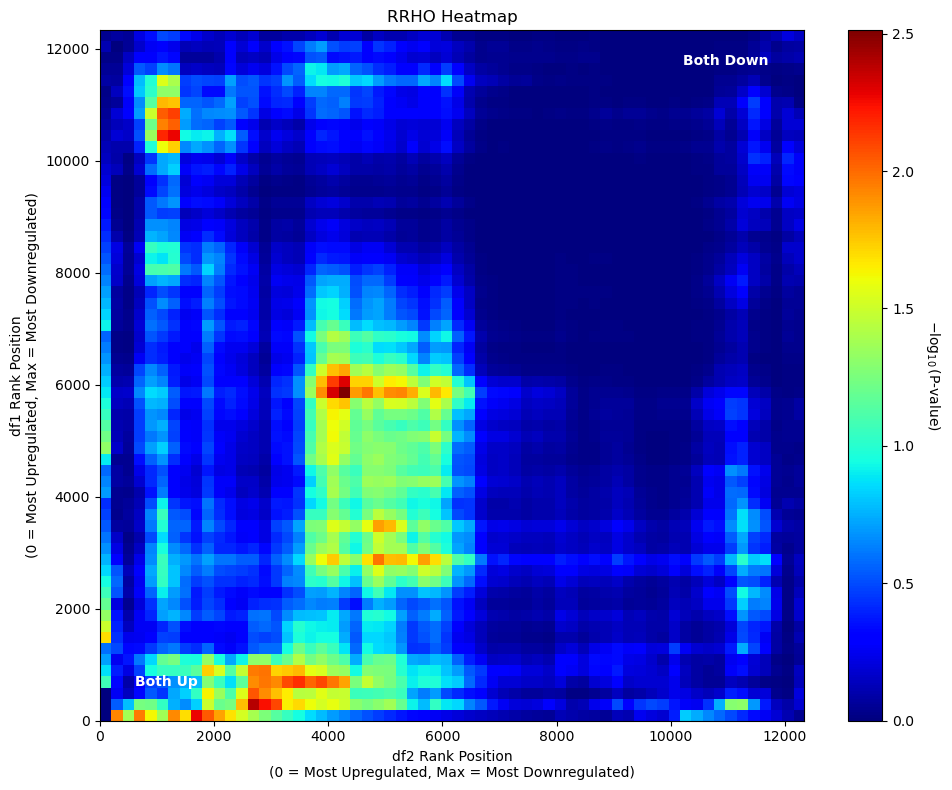

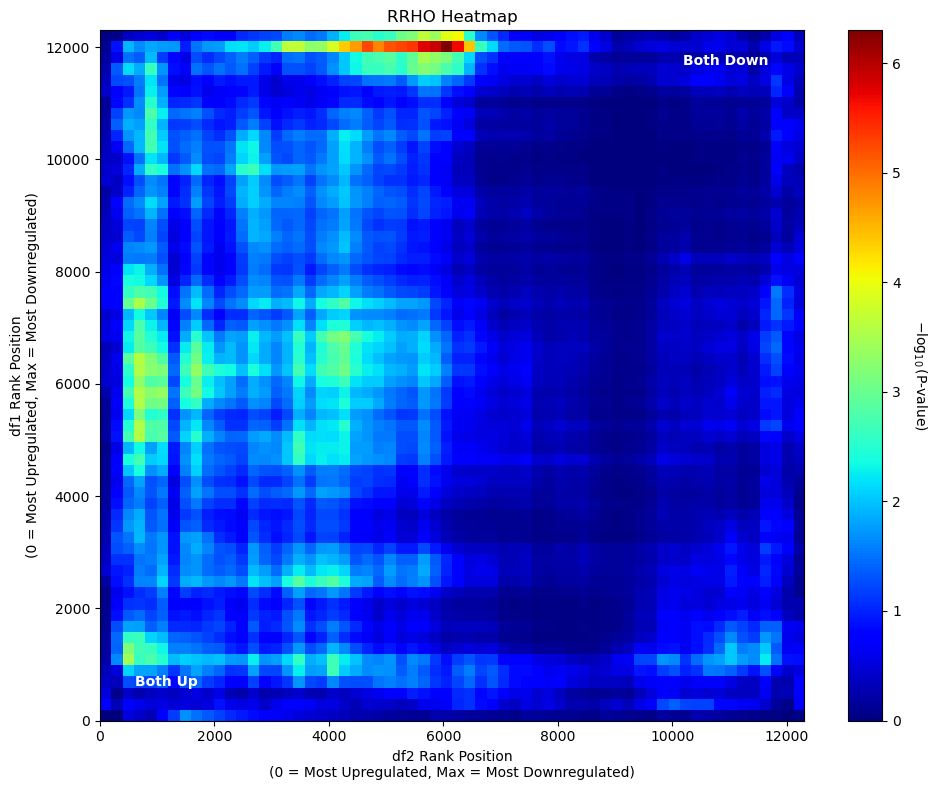

In [164]:
results_list = []

df2_transcripts = df2['upstream_gene'].unique()

for transcript in df2_transcripts:
    print(f"start {transcript}")

    parent_gene = get_parent_gene(transcript)
    
    df2_sub = df2[df2[clean+df2_upstream_col] == parent_gene]
    df1_sub = df1[df1[clean+df1_upstream_col] == parent_gene]
    df2_set = set(df2_sub['DOWNSTREAM_GENE'])
    df1_set = set(df1_sub['DOWNSTREAM_GENE'])

    gene_overlap_count = len(df2_set.intersection(df1_set))
    print(gene_overlap_count)
    
    
    # A. hypergeometric overlap
    total_overlap_count = len(df1_set.intersection(df2_set))
    sig_df2 = set(df2_sub[df2_sub[df2_significance_col]<0.05]['DOWNSTREAM_GENE'])
    sig_df1 = set(df1_sub[df1_sub[df1_significance_col]<0.05]['DOWNSTREAM_GENE'])
    sig_overlap_count = len(sig_df2.intersection(sig_df1))
    geo_p_value = stats.hypergeom.sf(sig_overlap_count - 1, total_overlap_count, len(sig_df2), len(sig_df1))

    print(f"sig_h: {len(sig_df2)}")
    print(f"sig_m: {len(sig_df1)}")
    print(f"sig_overlap_count: {sig_overlap_count}")
    print(f"total_overlap_count: {total_overlap_count}")
    print(f"geo_p_value: {geo_p_value}")
    
    #B. spearman 

    # 1. Sort by significance and drop duplicates so we only keep the strongest signal per ENSG
    df2_sub_unique = df2_sub.sort_values(df2_significance_col, ascending=True).drop_duplicates(subset=['DOWNSTREAM_GENE'])
    df1_sub_unique = df1_sub.sort_values(df1_significance_col, ascending=True).drop_duplicates(subset=['DOWNSTREAM_GENE'])

    # 2. Now perform a strict 1-to-1 merge
    merged = pd.merge(df2_sub_unique, df1_sub_unique, left_on='DOWNSTREAM_GENE', right_on='DOWNSTREAM_GENE')
    
    clean_merged = merged.dropna(subset=[df1_significance_col, df2_significance_col])
    clean_merged['combined_p'] = clean_merged[df1_significance_col] * clean_merged[df2_significance_col]
    clean_merged = clean_merged.sort_values('combined_p', ascending=True)
    note = 'N/A'

    if len(clean_merged) < 5:
        rho = 0
        p_rho = 1.0
        note = 'Not enough overlap'  
    elif clean_merged[df1_expression_col].nunique() <= 1 or clean_merged[df2_expression_col].nunique() <= 1:
        rho = 0
        p_rho = 1.0
        note = 'constant l2fc value'
    else:
        rho, p_rho = stats.spearmanr(clean_merged[df1_expression_col], clean_merged[df2_expression_col])

    #C. RRHO
    df1_number, df2_number, rrho_overlap, pval, map_data,best_df2_cut,best_df1_cut,max_rank = run_rrho(df1_sub, df2_sub, transcript,step_size=200)
    plot(map_data,transcript,max_rank)

    #E. Directional Overlap
    merged = clean_merged
    merged['prod'] = merged[df2_expression_col] * merged[df1_expression_col]
    dir_count = (merged['prod'] > 0).sum()
    
    sig_mask = (merged[df2_significance_col] < 0.05) & (merged[df1_significance_col] < 0.05)
    sig_merged = merged[sig_mask]
    
    sig_dir_count = ((sig_merged[df2_expression_col] * sig_merged[df1_expression_col]) > 0).sum()

    
    results_list.append({
        'DF2_Gene': transcript,
        'DF1_GENE': parent_gene,
        'Num_DF2_Genes': df2_number,
        'Num_DF1_Genes': df1_number,
        'Sig_DF2': len(sig_df2),
        'Sig_DF1': len(sig_df1),
        'Overlap_Count': gene_overlap_count,
        'Sig_Overlap_Count': sig_overlap_count,
        'Genes_Same_Dir': dir_count,
        'Sig_Genes_Same_Dir': sig_dir_count, 
        'Spearman_Rho': rho,
        'Spearman_P': p_rho,
        'Significant_Rho': p_rho < 0.05,
        'Hypergeometric_p': geo_p_value,
        'RRHO_Overlap_Count': rrho_overlap,
        'RRHO_P': f"{pval:.6f}",
        'Significant_Overlap': pval<0.05,
        'Note': note
    })
    print(f"df1 cut {best_df1_cut}")
    print(f"df2 cut {best_df2_cut}")
    print(f"done {transcript}")
    
    
results_df = pd.DataFrame(results_list)

In [165]:
results_df

,DF2_Gene,DF1_GENE,Num_DF2_Genes,Num_DF1_Genes,Sig_DF2,Sig_DF1,Overlap_Count,Sig_Overlap_Count,Genes_Same_Dir,Sig_Genes_Same_Dir,Spearman_Rho,Spearman_P,Significant_Rho,Hypergeometric_p,RRHO_Overlap_Count,RRHO_P,Significant_Overlap,Note
0,BANF1-201,BANF1,21736,20311,13,280,12153,0,5972,0,-0.015463,0.088267,False,1.000000,8,0.980198,False,N/A
1,DPF2-205,DPF2,44605,20744,219,508,12682,16,6157,5,-0.010614,0.231991,False,0.015071,1,0.821782,False,N/A
2,DPF2-208,DPF2,44605,20744,219,508,12682,16,6157,5,-0.010614,0.231991,False,0.015071,1,0.772277,False,N/A
3,EIF1AD-205,EIF1AD,44149,20018,18,200,12558,0,6193,0,-0.018656,0.036565,True,1.000000,1,0.009901,True,N/A
4,EIF1AD-211,EIF1AD,44149,20018,18,200,12558,0,6193,0,-0.018656,0.036565,True,1.000000,1,0.009901,True,N/A
5,FXR1-202,FXR1,46732,20913,15,731,12832,1,6331,1,-0.031442,0.000368,True,0.585343,1,0.643564,False,N/A
6,FXR1-206,FXR1,46732,20913,15,731,12832,1,6331,1,-0.031442,0.000368,True,0.585343,1,0.742574,False,N/A
7,MATR3-201,MATR3,70100,20530,47,934,12947,1,6239,1,0.006196,0.480871,False,0.970566,1,0.326733,False,N/A
8,MATR3-207,MATR3,70100,20530,47,934,12947,1,6239,1,0.006196,0.480871,False,0.970566,1,0.257426,False,N/A
9,MATR3-229,MATR3,70100,20530,47,934,12947,1,6239,1,0.006196,0.480871,False,0.970566,1,0.366337,False,N/A


In [95]:
results_df.to_csv(f'{output_dir}results_df.csv')